# OceanSODA

In [1]:
import xarray as xr

In [2]:
ds = xr.open_dataset("/global/cfs/projectdirs/m4746/Users/nora/Datasets/OceanSODA/OceanSODA_ETHZ-v2023.OCADS.01_1982-2022.nc")

In [3]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:          (time: 492, lat: 180, lon: 360, region: 4)
Coordinates:
  * time             (time) datetime64[ns] 4kB 1982-01-15 ... 2022-12-15
  * lat              (lat) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon              (lon) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * region           (region) <U7 112B 'global' 'north' 'tropics' 'south'
Data variables: (12/28)
    talk             (time, lat, lon) float32 128MB ...
    dic              (time, lat, lon) float32 128MB ...
    spco2            (time, lat, lon) float32 128MB ...
    sfco2            (time, lat, lon) float32 128MB ...
    ph_total         (time, lat, lon) float32 128MB ...
    ph_free          (time, lat, lon) float32 128MB ...
    ...               ...
    area             (lat, lon) float32 259kB ...
    fgco2_reg        (region, time) float32 8kB ...
    area_reg         (region) float32 16B ...
    ice              (time, lat, lon) float32 128MB ...
    kw               (time, lat, lon) float32 128MB ...
    sol              (time, lat, lon) float32 128MB ...
Attributes:
    contact:      gregorl@ethz.ch
    author:       Luke Gregor
    institution:  ETH Zuerich
    version:      v2023.GCB
    date:         2023-06-26
    description:  talk and pco2 (more accurately fco2) are estimated with two...
    changelog:    v2021d: Extended from 1982-2020; Now using: OISSTv2.1 for S...
    reference:    Gregor, L. and Gruber, N.: OceanSODA-ETHZ: A global gridded...
    source:       https://doi.org/10.25921/m5wx-ja34
    product:      OSETHZ-v2023.GCB

Since March 1982 has some crazy values, let's restrict to the last available 30 years: 1993 - 2022

In [4]:
ds = ds.isel(time=slice(12*11, None))

In [5]:
ds = ds.drop_vars(
    [
        "spco2", "sfco2", "ph_total", "ph_free", "hco3", "co3", "co2", 
        "revelle_factor", "omega_ca", "omega_ar", "dic_uncert", "spco2_uncert",
        "ph_total_uncert", "omega_ca_uncert", "omega_ar_uncert", "talk_uncert",
        "sfco2_uncert", "fgco2", "area", "fgco2_reg", "area_reg", "ice", "kw", "sol"
    ]
)

In [6]:
ds

<xarray.Dataset> Size: 373MB
Dimensions:      (time: 360, lat: 180, lon: 360, region: 4)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1993-01-15 1993-02-15 ... 2022-12-15
  * lat          (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon          (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * region       (region) <U7 112B 'global' 'north' 'tropics' 'south'
Data variables:
    talk         (time, lat, lon) float32 93MB ...
    dic          (time, lat, lon) float32 93MB ...
    temperature  (time, lat, lon) float32 93MB ...
    salinity     (time, lat, lon) float32 93MB ...
Attributes:
    contact:      gregorl@ethz.ch
    author:       Luke Gregor
    institution:  ETH Zuerich
    version:      v2023.GCB
    date:         2023-06-26
    description:  talk and pco2 (more accurately fco2) are estimated with two...
    changelog:    v2021d: Extended from 1982-2020; Now using: OISSTv2.1 for S...
    reference:    Gregor, L. and Gruber, N.: OceanSODA-ETHZ: A global gridded...
    source:       https://doi.org/10.25921/m5wx-ja34
    product:      OSETHZ-v2023.GCB

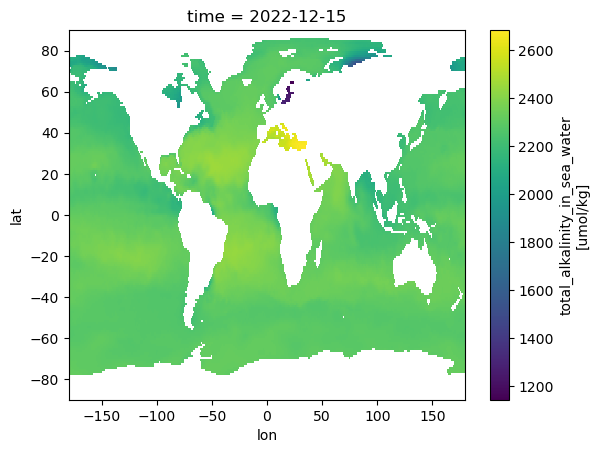

In [7]:
ds.talk.isel(time=-1).plot()

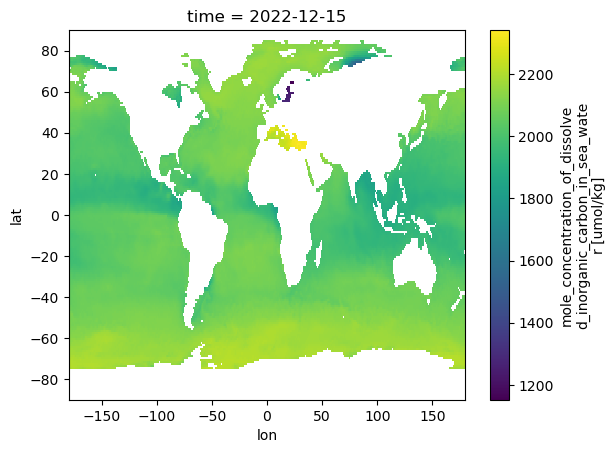

In [8]:
ds.dic.isel(time=-1).plot()

## Compute carbonate sensitivities

\begin{equation}
    \beta = \frac{\partial[{DIC}]}{\partial[{CO_2}]} = \frac{[{DIC}]}{[{CO_2}]} - \frac{[HCO^-_3] + 2[CO_3^{2-}]}{[{CO_2}]} \frac{\partial [{DIC}]}{\partial [{ALK}]}
\end{equation}

We have

\begin{equation}
    \eta = \frac{\partial [DIC]}{\partial [ALK]}
\end{equation}

`csys["isocapnic_quotient"]` is the inverse of $\eta$.

In [11]:
import PyCO2SYS as pyco2
from typing import Tuple

In [12]:
def compute_sensitivities(
    ds: xr.Dataset,
) -> Tuple[xr.DataArray, xr.DataArray]:
    """
    Compute carbonate sensitivities using PyCO2SYS.

    beta = dDIC / dCO2
    eta  = dDIC / dALK

    Assumes `ds` contains only surface variables
    (e.g., ds = ds.isel(s_rho=-1)).

    Parameters
    ----------
    ds : xr.Dataset
        Dataset containing surface ALK, DIC, salt, temperature,

    Returns
    -------
    beta : xr.DataArray
        dDIC / dCO2 sensitivity.
    eta : xr.DataArray
        dDIC / dALK sensitivity.
    """

    csys = pyco2.sys(
        par1=ds["talk"],
        par2=ds["dic"],
        par1_type=1,
        par2_type=2,
        salinity=ds["salinity"],
        temperature=ds["temperature"],
        total_silicate = 0.5, # umol/kg
        total_phosphate = 2 # umol/kg
    )

    iso_q = csys["isocapnic_quotient"]

    beta = (
        csys["dic"]
        - (csys["HCO3"] + 2.0 * csys["CO3"]) / iso_q
    ) / csys["CO2"]

    eta = 1.0 / iso_q

    return beta, eta

In [14]:
beta, eta = compute_sensitivities(ds)

In [15]:
ds_carbonate_sensitivity = xr.Dataset(
    {
        "time": ds["time"],
        "lat": ds["lat"],
        "lon": ds["lon"],
        "dDICdCO2": xr.DataArray(beta, dims=["time", "lat", "lon"]),
        "dDICdALK": xr.DataArray(eta, dims=["time", "lat", "lon"]),
    }
)

In [16]:
ds_carbonate_sensitivity

<xarray.Dataset> Size: 373MB
Dimensions:   (time: 360, lat: 180, lon: 360)
Coordinates:
  * time      (time) datetime64[ns] 3kB 1993-01-15 1993-02-15 ... 2022-12-15
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Data variables:
    dDICdCO2  (time, lat, lon) float64 187MB nan nan nan nan ... nan nan nan nan
    dDICdALK  (time, lat, lon) float64 187MB nan nan nan nan ... nan nan nan nan

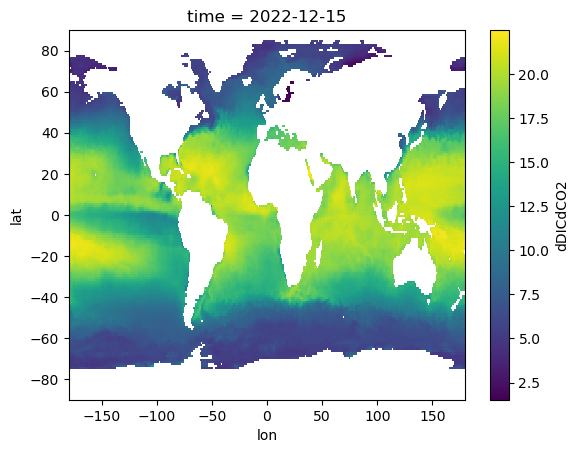

In [17]:
ds_carbonate_sensitivity.dDICdCO2.isel(time=-1).plot()

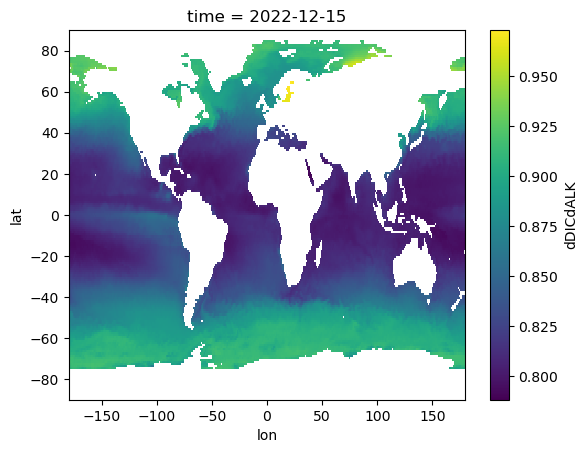

In [18]:
ds_carbonate_sensitivity.dDICdALK.isel(time=-1).plot()

### Save to NetCDF

In [19]:
ds_carbonate_sensitivity.to_netcdf("/global/cfs/projectdirs/m4746/Users/nora/Datasets/OceanSODA/OceanSODA_carbonate_sensitivity.nc")